In [128]:
# Generate m87-esque image from equatorial emision model
import numpy as np
import ehtim as eh
import matplotlib.pyplot as plt
from kgeo.equatorial_images import make_image
from kgeo.bfields import Bfield
from kgeo.velocities import Velocity
#from kgeo.emissivities import Emissivity
import importlib, kgeo.emissivities as em
importlib.reload(em)
from kgeo.emissivities import Emissivity

# file label
label='test'
save_image = False
display_image = True

# source and image parameters
source = 'M87'
MBH = 6.5e9       # solar masses
rg = 147700*MBH   # cm
MoD = 3.82 #3.77883459  # this is what was used for M/D in uas for the M87 simulations
ra = 12.51373 
dec = 12.39112 
flux230 = 0.6     # total flux
npix = 512        # number of pixels
amax = 15         # maximum alpha,beta in R
f0 = 1            # scaling factor for n=0 flux
f1 = 1            # scaling factor for n=1 flux
f2 = 1            # scaling factor for n>=2 flux
nmax = 2          # maximum subring number
rotation = 0#-90*eh.DEGREE  # rotation angle, for m87 prograde=90,retrograde=-90 (used in display only)
polarization = True      # make polarized image or not
pathlength = True        # include disk pathlength factor or not
specind = 1              # spectral index
nu_obs = 230.e9          # frequency
bfield_model = True      # input bfield model into emissivities model
p_val = 0.5
n_I = -3/2

# bh and observer parameters
th_o = 163*np.pi/180.  # inclination angle, does not work for th0=0 exactly!
spin = 0.9             # black hole spin, does not work for a=0 or a=1 exactly!
r_o = np.inf           # outer radius
                 
# bfield model
#bfield = Bfield("simple", Cr=0.87, Cvert=0, Cph=0.5)
#bfield = Bfield("simple_rm1", Cr=0.87, Cvert=0, Cph=0.5) 
#bfield = Bfield("const_comoving", Cr=0.5, Cvert=0, Cph=0.87) 
#bfield = Bfield("bz_monopole",C=1)
#bfield = Bfield("bz_guess",C=1)
#bfield = Bfield("simple", Cr=0, Cvert=1, Cph=0)
bfield = Bfield('gen_power', p_val = p_val, n_I = n_I,  isAbove = True)

# velocity model
#velocity = Velocity('simfit') # note simfit model will not work for all spins!
#velocity = Velocity('gelles', gelles_beta=0.3, gelles_chi=-120*np.pi/180.)
velocity = Velocity('subkep', retrograde=False, fac_subkep=0.7)
#velocity = Velocity('general', retrograde=False, fac_subkep=0.7, beta_phi=0.5, beta_r=0.5)
#velocity = Velocity('kep',retrograde=False)
#velocity = Velocity('driftframe', bfield=bfield, nu_parallel=0)  


# emissivity model
#emissivity = Emissivity("ring", r_ring=4, sigma=0.3, emiscut_in=3.5, emiscut_out=4.5)
#emissivity = Emissivity("ring", r_ring=6, sigma=0.3, emiscut_in=5.5, emiscut_out=6.5)
#emissivity = Emissivity("glm", sigma=0.5, gamma_off=-1)
#emissivity = Emissivity("bpl", p1=-2.0, p2=-0.5)
emissivity = Emissivity('thermal', R0=5.0, ne0=1e7, Te0=5e10, B0=10, alpha_n=1.0, alpha_T=1.0, alpha_B=1.0, bfield_model = True, p_val = p_val, n_I = n_I)

Emissivity emistype = 'thermal'


In [143]:
a_plt = 0.5
r_h = 1 + np.sqrt(1 - (a_plt * a_plt))
r_plt = np.linspace(r_h + 0.1, 10, 300)  
p_val = 0.5
n_I = -3/2
vel = Velocity('kep',retrograde=False)

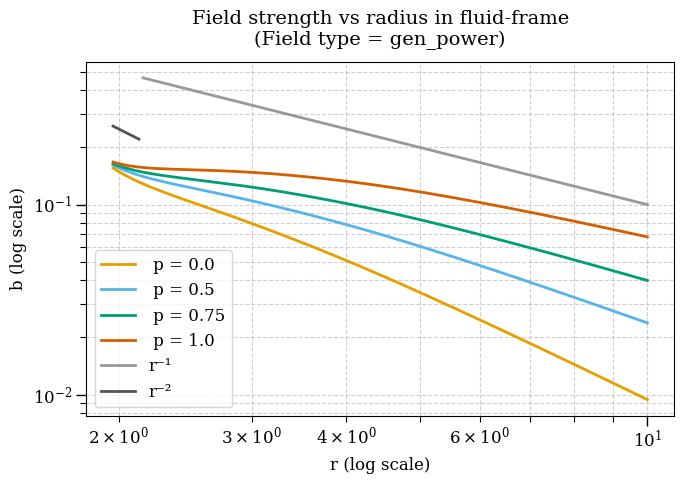

In [145]:
p_vala = 0.0
p_valb = 0.5
p_valc = 0.75
p_vald = 1.0

bfield_plta = Bfield('gen_power', n_I=n_I, p_val=p_vala, isAbove = True)
bfield_pltb = Bfield('gen_power', n_I=n_I, p_val=p_valb, isAbove = True)
bfield_pltc = Bfield('gen_power', n_I=n_I, p_val=p_valc, isAbove = True)
bfield_pltd = Bfield('gen_power', n_I=n_I, p_val=p_vald, isAbove = True)

b_model_a = np.sqrt(bfield_plta.bsq(a_plt, r_plt, vel, th=np.pi/2))
b_model_b = np.sqrt(bfield_pltb.bsq(a_plt, r_plt, vel, th=np.pi/2))
b_model_c = np.sqrt(bfield_pltc.bsq(a_plt, r_plt, vel, th=np.pi/2))
b_model_d = np.sqrt(bfield_pltd.bsq(a_plt, r_plt, vel, th=np.pi/2))

fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(r_plt, b_model_a, linewidth=2, color="#E69F00", label=f" p = {p_vala}")
ax.loglog(r_plt, b_model_b, linewidth=2, color="#56B4E9", label=f" p = {p_valb}")
ax.loglog(r_plt, b_model_c, linewidth=2, color="#009E73", label=f" p = {p_valc}")
ax.loglog(r_plt, b_model_d, linewidth=2, color="#D55E00", label=f" p = {p_vald}")

# fix slope -1, -2 lines
rmin1, rmax1 = 2.15, np.max(r_plt)
rmin2, rmax2 = 0, 2.15
b = r_plt[0]**-1 - r_plt[0]**-2 
mask1 = (r_plt >= rmin1) & (r_plt <= rmax1)
mask2 = (r_plt >= rmin2) & (r_plt <= rmax2)
ax.loglog(r_plt[mask1], r_plt[mask1]**-1, linewidth=2, color="#999999", label="r" + "\u207B" + "\u00B9")
ax.loglog(r_plt[mask2], r_plt[mask2]**-2, linewidth=2, color="#545353", label="r" + "\u207B" + "\u00B2")

ax.set_title(f"Field strength vs radius in fluid-frame\n(Field type = {getattr(bfield_plta, "fieldtype", "")})", fontsize=14, pad=12)
ax.set_xlabel("r (log scale)", fontsize=12)
ax.set_ylabel("b (log scale)", fontsize=12)
ax.grid(True, which="both", linestyle="--", alpha=0.6)
ax.tick_params(axis="both", which="major", length=7, width=1)
ax.tick_params(axis="both", which="minor", length=4, width=0.8)
ax.legend()
fig.tight_layout()
plt.show()

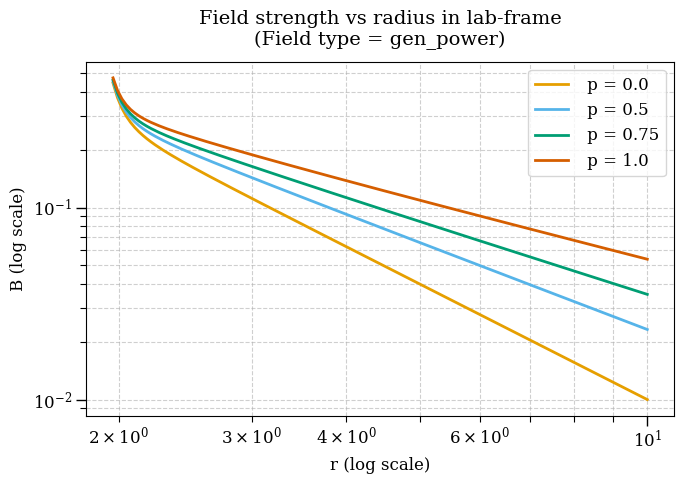

In [146]:
p_vala = 0.0
p_valb = 0.5
p_valc = 0.75
p_vald = 1.0

bfield_plta = Bfield('gen_power', n_I=n_I, p_val=p_vala, isAbove = True)
bfield_pltb = Bfield('gen_power', n_I=n_I, p_val=p_valb, isAbove = True)
bfield_pltc = Bfield('gen_power', n_I=n_I, p_val=p_valc, isAbove = True)
bfield_pltd = Bfield('gen_power', n_I=n_I, p_val=p_vald, isAbove = True)

B1a, B2a, B3a = bfield_plta.bfield_lab(a_plt, r_plt, th=np.pi/2)
Ba = np.sqrt(B1a**2 + B2a**2 + B3a**2)

B1b, B2b, B3b = bfield_pltb.bfield_lab(a_plt, r_plt, th=np.pi/2)
Bb = np.sqrt(B1b**2 + B2b**2 + B3b**2)

B1c, B2c, B3c = bfield_pltc.bfield_lab(a_plt, r_plt, th=np.pi/2)
Bc = np.sqrt(B1c**2 + B2c**2 + B3c**2)

B1d, B2d, B3d = bfield_pltd.bfield_lab(a_plt, r_plt, th=np.pi/2)
Bd = np.sqrt(B1d**2 + B2d**2 + B3d**2)

fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(r_plt, Ba, linewidth=2, color="#E69F00", label=f" p = {p_vala}")
ax.loglog(r_plt, Bb, linewidth=2, color="#56B4E9", label=f" p = {p_valb}")
ax.loglog(r_plt, Bc, linewidth=2, color="#009E73", label=f" p = {p_valc}")
ax.loglog(r_plt, Bd, linewidth=2, color="#D55E00", label=f" p = {p_vald}")

rmin1, rmax1 = 2.15, np.max(r_plt)
rmin2, rmax2 = 0, 2.15
b = r_plt[0]**-1 - r_plt[0]**-2 

mask1 = (r_plt >= rmin1) & (r_plt <= rmax1)
mask2 = (r_plt >= rmin2) & (r_plt <= rmax2)
#ax.loglog(r_plt[mask1], r_plt[mask1]**-1, linewidth=2, color="#999999", label="r" + "\u207B" + "\u00B9")
#ax.loglog(r_plt[mask2], r_plt[mask2]**-2, linewidth=2, color="#545353", label="r" + "\u207B" + "\u00B2")

ax.set_title(f"Field strength vs radius in lab-frame\n(Field type = {getattr(bfield_plta, "fieldtype", "")})", fontsize=14, pad=12)
ax.set_xlabel("r (log scale)", fontsize=12)
ax.set_ylabel("B (log scale)", fontsize=12)
ax.grid(True, which="both", linestyle="--", alpha=0.6)
ax.tick_params(axis="both", which="major", length=7, width=1)
ax.tick_params(axis="both", which="minor", length=4, width=0.8)
ax.legend()
fig.tight_layout()
plt.show()

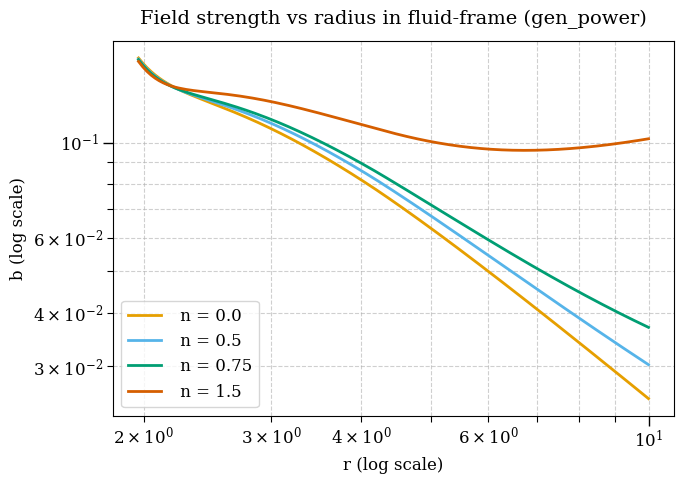

In [147]:
n_vala = 0.0
n_valb = 0.5
n_valc = 0.75
n_vald = 1.5

bfield_plta = Bfield('gen_power', n_I=n_vala, p_val=p_val, isAbove = True)
bfield_pltb = Bfield('gen_power', n_I=n_valb, p_val=p_val, isAbove = True)
bfield_pltc = Bfield('gen_power', n_I=n_valc, p_val=p_val, isAbove = True)
bfield_pltd = Bfield('gen_power', n_I=n_vald, p_val=p_val, isAbove = True)

vel = Velocity('kep',retrograde=False)

b_model_a = np.sqrt(bfield_plta.bsq(a_plt, r_plt, vel, th=np.pi/2))
b_model_b = np.sqrt(bfield_pltb.bsq(a_plt, r_plt, vel, th=np.pi/2))
b_model_c = np.sqrt(bfield_pltc.bsq(a_plt, r_plt, vel, th=np.pi/2))
b_model_d = np.sqrt(bfield_pltd.bsq(a_plt, r_plt, vel, th=np.pi/2))

fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(r_plt, b_model_a, linewidth=2, color="#E69F00", label=f" n = {n_vala}")
ax.loglog(r_plt, b_model_b, linewidth=2, color="#56B4E9", label=f" n = {n_valb}")
ax.loglog(r_plt, b_model_c, linewidth=2, color="#009E73", label=f" n = {n_valc}")
ax.loglog(r_plt, b_model_d, linewidth=2, color="#D55E00", label=f" n = {n_vald}")

ax.set_title(f"Field strength vs radius in fluid-frame ({getattr(bfield_plta, "fieldtype", "")})", fontsize=14, pad=12)
ax.set_xlabel("r (log scale)", fontsize=12)
ax.set_ylabel("b (log scale)", fontsize=12)
ax.grid(True, which="both", linestyle="--", alpha=0.6)
ax.tick_params(axis="both", which="major", length=7, width=1)
ax.tick_params(axis="both", which="minor", length=4, width=0.8)
ax.legend()
fig.tight_layout()
plt.show()

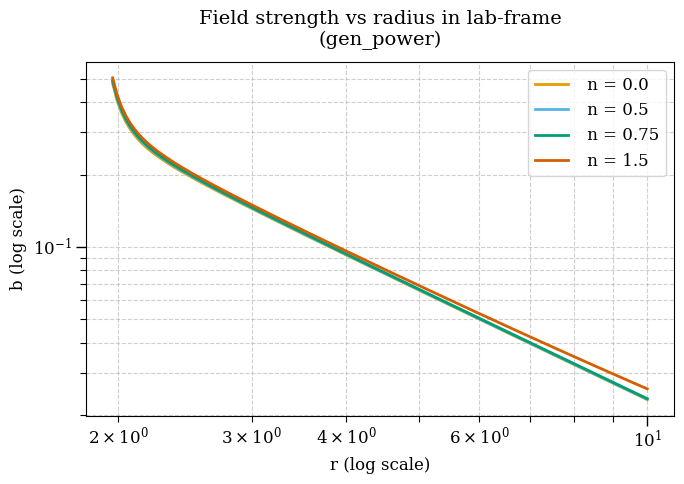

In [148]:
n_vala = 0.0
n_valb = 0.5
n_valc = 0.75
n_vald = 1.5

bfield_plta = Bfield('gen_power', n_I=n_vala, p_val=p_val, isAbove = True)
bfield_pltb = Bfield('gen_power', n_I=n_valb, p_val=p_val, isAbove = True)
bfield_pltc = Bfield('gen_power', n_I=n_valc, p_val=p_val, isAbove = True)
bfield_pltd = Bfield('gen_power', n_I=n_vald, p_val=p_val, isAbove = True)

B1a, B2a, B3a = bfield_plta.bfield_lab(a_plt, r_plt, th=np.pi/2)
Ba = np.sqrt(B1a**2 + B2a**2 + B3a**2)

B1b, B2b, B3b = bfield_pltb.bfield_lab(a_plt, r_plt, th=np.pi/2)
Bb = np.sqrt(B1b**2 + B2b**2 + B3b**2)

B1c, B2c, B3c = bfield_pltc.bfield_lab(a_plt, r_plt, th=np.pi/2)
Bc = np.sqrt(B1c**2 + B2c**2 + B3c**2)

B1d, B2d, B3d = bfield_pltd.bfield_lab(a_plt, r_plt, th=np.pi/2)
Bd = np.sqrt(B1d**2 + B2d**2 + B3d**2)

fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(r_plt, Ba, linewidth=2, color="#E69F00", label=f" n = {n_vala}")
ax.loglog(r_plt, Bb, linewidth=2, color="#56B4E9", label=f" n = {n_valb}")
ax.loglog(r_plt, Bc, linewidth=2, color="#009E73", label=f" n = {n_valc}")
ax.loglog(r_plt, Bd, linewidth=2, color="#D55E00", label=f" n = {n_vald}")

ax.set_title(f"Field strength vs radius in lab-frame\n({getattr(bfield_plta, "fieldtype", "")})", fontsize=14, pad=12)
ax.set_xlabel("r (log scale)", fontsize=12)
ax.set_ylabel("b (log scale)", fontsize=12)
ax.grid(True, which="both", linestyle="--", alpha=0.6)
ax.tick_params(axis="both", which="major", length=7, width=1)
ax.tick_params(axis="both", which="minor", length=4, width=0.8)
ax.legend()
fig.tight_layout()
plt.show()

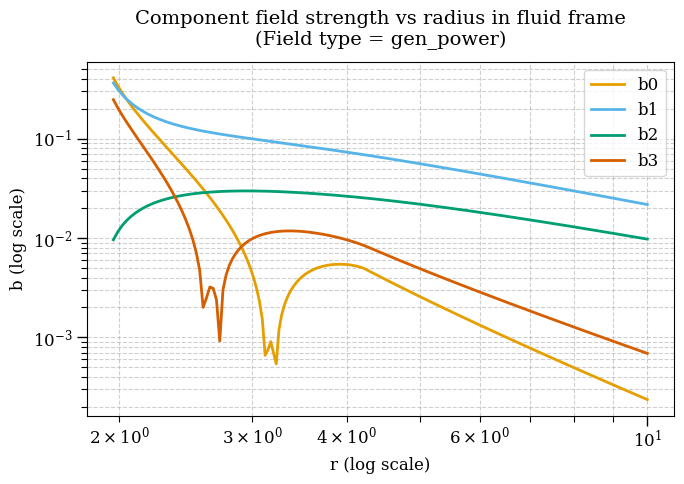

In [149]:
bfield_plt = Bfield('gen_power', n_I=n_I, p_val=p_val, isAbove = True)
vel = Velocity('kep',retrograde=False)

(b0, b1, b2, b3), (b0_l, b1_l, b2_l, b3_l) = bfield_plt.bsq_comp(a_plt, r_plt, vel, th=np.pi/2)
b_0 = np.sqrt(np.abs(b0 *b0_l))
b_1 = np.sqrt(b1 *b1_l)
b_2 = np.sqrt(b2 *b2_l)
b_3 = np.sqrt(np.abs(b3 *b3_l))

fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(r_plt, b_0, linewidth=2, color="#E69F00", label=f"b0")
ax.loglog(r_plt, b_1, linewidth=2, color="#56B4E9", label=f"b1")
ax.loglog(r_plt, b_2, linewidth=2, color="#009E73", label=f"b2")
ax.loglog(r_plt, b_3, linewidth=2, color="#D55E00", label=f"b3")

ax.set_title(f"Component field strength vs radius in fluid frame\n(Field type = {getattr(bfield_plt, "fieldtype", "")})", fontsize=14, pad=12)
ax.set_xlabel("r (log scale)", fontsize=12)
ax.set_ylabel("b (log scale)", fontsize=12)
ax.grid(True, which="both", linestyle="--", alpha=0.6)
ax.tick_params(axis="both", which="major", length=7, width=1)
ax.tick_params(axis="both", which="minor", length=4, width=0.8)
ax.legend()
fig.tight_layout()
plt.show()

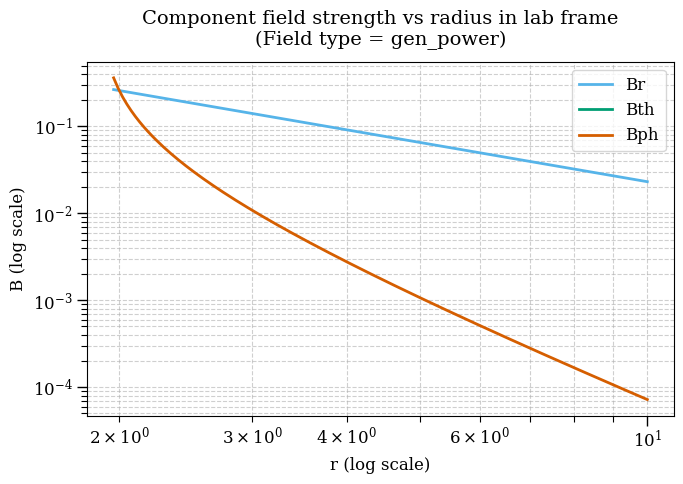

In [150]:
# when isAbove = False, plot is empty ??
bfield_plt = Bfield('gen_power', n_I=n_I, p_val=p_val, isAbove = True)

Br, Bth, Bph = bfield_plt.bfield_lab(a_plt, r_plt, th=np.pi/2)

fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(r_plt, Br, linewidth=2, color="#56B4E9", label=f"Br")
ax.loglog(r_plt, Bth, linewidth=2, color="#009E73", label=f"Bth")
ax.loglog(r_plt, Bph, linewidth=2, color="#D55E00", label=f"Bph")

ax.set_title(f"Component field strength vs radius in lab frame\n(Field type = {getattr(bfield_plt, "fieldtype", "")})", fontsize=14, pad=12)
ax.set_xlabel("r (log scale)", fontsize=12)
ax.set_ylabel("B (log scale)", fontsize=12)
ax.grid(True, which="both", linestyle="--", alpha=0.6)
ax.tick_params(axis="both", which="major", length=7, width=1)
ax.tick_params(axis="both", which="minor", length=4, width=0.8)
ax.legend()
fig.tight_layout()
plt.show()

In [151]:
bf = Bfield(fieldtype='gen_power', n=0, p=0.5, isAbove=True)
r = np.array([2.0, 3.0, 5.0])

# magnetic field
B1,B2,B3 = bf.bfield_lab(a=0.5, r=r)   # ok

# angular speed
w = bf.omega_field(a=0.5, r=r)         # ok

# E-field / tensors
E1,E2,E3 = bf.efield_lab(a=0.5, r=r)   # ok after fix #1
sF = bf.maxwell(a=0.5, r=r)            # already ok
F  = bf.faraday(a=0.5, r=r) 

In [152]:
################################################################################################################
plt.close('all')

# generate the equatorial model image arrays
psize = 2.*amax/npix
imagedat = make_image(spin,r_o, th_o, nmax, -amax, amax, -amax, amax, psize,
                      nmax_only=False,
                      emissivity=emissivity,velocity=velocity, bfield=bfield,
                      polarization=polarization, pathlength=pathlength, specind=specind, nu_obs=nu_obs)
                      


# mask nans and add up the subrings
if pathlength:
    (outarr_I, outarr_Q, outarr_U, outarr_r, outarr_t, outarr_g, outarr_sinthb, outarr_n, outarr_np,outarr_lp, outarr_Ie) = imagedat
else:
    (outarr_I, outarr_Q, outarr_U, outarr_r, outarr_t, outarr_g, outarr_sinthb, outarr_n, outarr_np) = imagedat

nanmask = np.isnan(outarr_I)
print("NaNs: ", np.sum(nanmask))
outarr_I[nanmask] = 0
outarr_Q[nanmask] = 0
outarr_U[nanmask] = 0

imarr0 = np.flipud(outarr_I[:,0].reshape(npix,npix))
imarr1 = np.flipud(outarr_I[:,1].reshape(npix,npix))
imarrRings = np.flipud(np.sum(outarr_I[:,2:],axis=1).reshape(npix,npix))

imarr = f0*imarr0 + f1*imarr1 + f2*imarrRings
if np.sum(imarr)==0:
    raise Exception("no flux in output image!")
    
if polarization:
    imarr0_Q = np.flipud(outarr_Q[:,0].reshape(npix,npix))
    imarr1_Q = np.flipud(outarr_Q[:,1].reshape(npix,npix))
    imarrRings_Q = np.flipud(np.sum(outarr_Q[:,2:],axis=1).reshape(npix,npix))
    
    imarr_Q = f0*imarr0_Q + f1*imarr1_Q + f2*imarrRings_Q

    imarr0_U = np.flipud(outarr_U[:,0].reshape(npix,npix))
    imarr1_U = np.flipud(outarr_U[:,1].reshape(npix,npix))
    imarrRings_U = np.flipud(np.sum(outarr_U[:,2:],axis=1).reshape(npix,npix))
    
    imarr_U = f0*imarr0_U + f1*imarr1_U + f2*imarrRings_U
    
# make an Image, normalize and save

thermal_emis = getattr(emissivity, "emistype", "") == "thermal"

if thermal_emis and pathlength:
    psize_rad = psize*MoD*eh.RADPERUAS
    Omega_p  = psize_rad**2 # sky area per pixel in sr/pixel
    to_Jy_per_p = rg * Omega_p / 1e-23  # this factor converts erg s^-1 cm^-3 Hz^-1 sr^-1 * M to Jy/pix
    imarr*= to_Jy_per_p 
    if polarization:
        imarr_U *= to_Jy_per_p 
        imarr_Q *= to_Jy_per_p 


fluxscale = flux230/np.sum(imarr)
print("fluxscale =", fluxscale)

im = eh.image.Image(imarr*fluxscale, psize_rad, ra, dec, rf=nu_obs)
#im.imvec[im.imvec==0]=+1.e-60

if polarization:
    im.add_qu(imarr_Q*fluxscale, imarr_U*fluxscale)

im.source = source
if save_image: im.save_fits('./m87_model_%s.fits'%label)

image 0...0.46 s
image 1...0.24 s
image 2...0.24 s
NaNs:  0
fluxscale = 0.006469115718757279


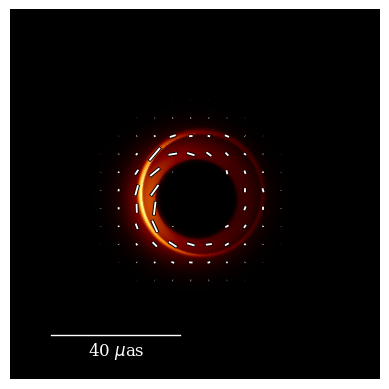

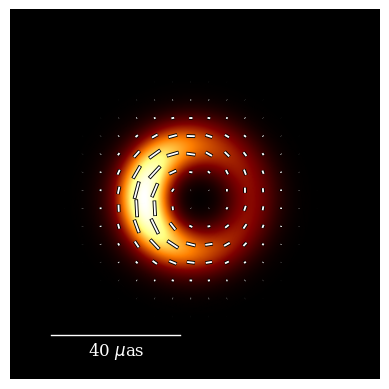

In [153]:
# display image
if display_image:
    im.rotate(rotation).display(
                 cbar_unit=['Tb'],has_cbar=False,label_type='scale',has_title=False,
                 plotp=polarization,pcut=.001,scale_ticks=True,nvec=20)
    im.blur_circ(10*eh.RADPERUAS,10*eh.RADPERUAS).rotate(rotation).display(
                 cbar_unit=['Tb'],has_cbar=False,label_type='scale',has_title=False,
                 plotp=polarization,pcut=.001,scale_ticks=True,nvec=20)

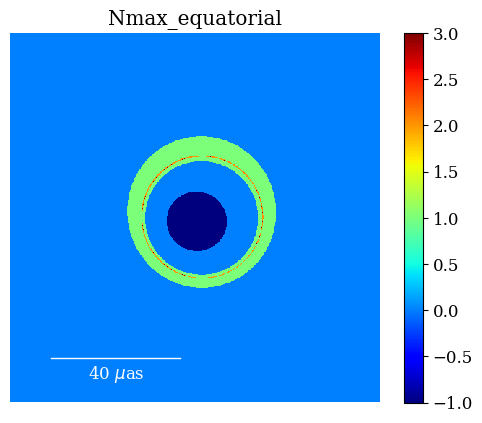

In [154]:
# make a image of the subring number and save
narr = np.flipud(outarr_n.reshape(npix,npix))   # number of equatorial crossings
narr[narr==-2]=-1 # mask out vortical geodesics
imn = eh.image.Image(narr, psize_rad, ra, dec)
imn.source = source
if save_image: imn.save_fits('./m87_model_%s_n.fits'%label)
if display_image: 
    imn.display(label_type='scale',cfun='jet',has_cbar=False,interp=None,show=False)
    plt.title('Nmax_equatorial');
    plt.colorbar(label='')
    

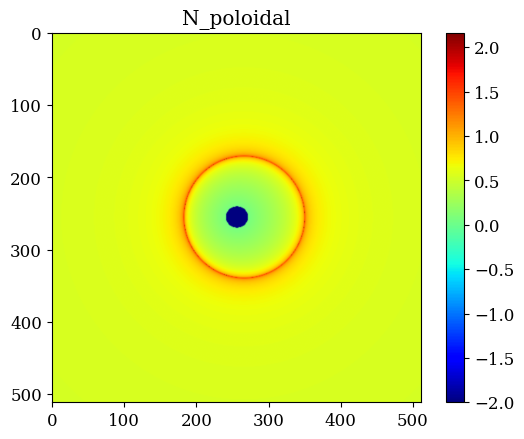

In [155]:
nparr = np.flipud(outarr_np.reshape(npix,npix)) # fractional number of poloidal orbits
imnp = eh.image.Image(nparr, psize_rad, ra, dec)
imnp.source = source
if save_image:  imnp.save_fits('./m87_model_%s_np.fits'%label)
if display_image: 
    imnp.display(label_type='jet',cfun='jet',has_cbar=False,show=False)
    plt.title('N_poloidal')
    plt.colorbar(label='')
    

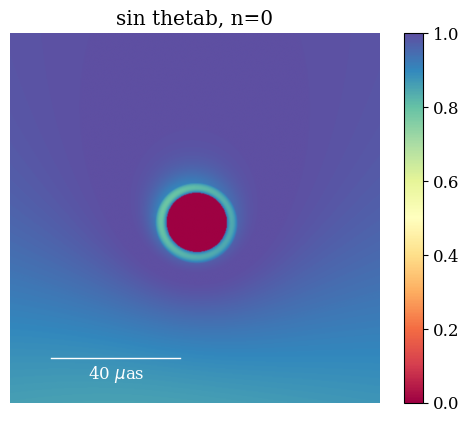

In [156]:
if polarization:
    # make a image of the n=0 sin^theta term and save
    stharr = np.flipud(outarr_sinthb[:,0].reshape(npix,npix))   # sin(theta)
    imsth = eh.image.Image(stharr, psize_rad, ra, dec)
    #imsth = eh.image.Image(stharr**2/np.max(stharr**2), psize_rad, ra, dec)
    imsth.source = source
    if save_image:  imsth.save_fits('./m87_model_%s_sinthb.fits'%label)
    if display_image: 
        imsth.rotate(rotation).display(label_type='scale',cfun='Spectral',has_cbar=False,show=False)
        plt.title('sin thetab, n=0')
        plt.colorbar(label='')

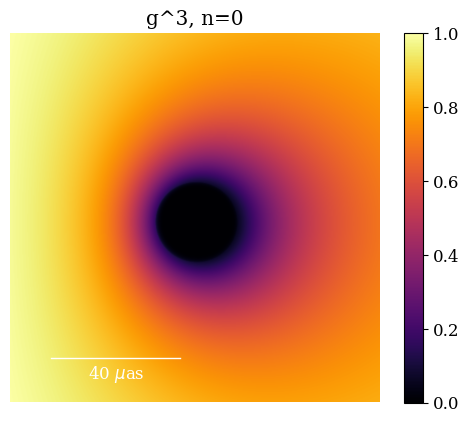

In [157]:
if polarization:
    # make a image of the n=0 doppler factor and save
    garr = np.flipud(outarr_g[:,0].reshape(npix,npix))   # number of equatorial crossings
    img = eh.image.Image(garr**3/np.max(garr**3), psize_rad, ra, dec)
    img.source = source
    if save_image:  img.save_fits('./m87_model_%s_g3.fits'%label)
    if display_image: 
        img.rotate(rotation).display(label_type='scale',cfun='inferno',has_cbar=False,show=False)
        plt.title('g^3, n=0')
        plt.colorbar(label='')